In [1]:
%load_ext autoreload
%autoreload 2

# Notebook cells for the BDT / fit-variable decorrelation study.
 
# %% [0] setup
import uproot, numpy as np, pandas as pd, matplotlib.pyplot as plt
import sys
sys.path.append('/home/belle/zhangboy/inclusive_R_D/')
import utilities as util
 
training_variables = util.training_variables
columns = util.all_relevant_variables
SAMPLES = '/home/belle/zhangboy/inclusive_R_D/Samples'
mode = 'e'   # repeat everything with 'mu'

In [2]:
# %% [1] regenerate PRE-LOOSE, candidate-level signal MC with BDT outputs (run once)
# written to a NEW file so the existing MC16rd_signals.root is never touched
out = {}
for m in ['e', 'mu']:
    df = uproot.concatenate([f'{SAMPLES}/MC16rd/signal*_deimos_1.root:B0_{m}'],
                             library='pd', cut=util.offline_cut,
                             filter_branch=lambda b: b.name in columns)
    util.add_derived_variables([df])
    print(df.index.equals(pd.RangeIndex(len(df))))   # False confirms the diagnosis
    # cut='ell_p>0' is always true -> no MVA cut; bcs=None keeps every candidate
    df_all = util.apply_mva_bcs(df, training_variables, cut='ell_p>0', library='lgbm',
                                model='multiclass', bcs=None)
    out[f'MC_{m}_all'] = df_all
with uproot.recreate(f'{SAMPLES}/MC16rd_signals_candidates.root') as f:
    for tree, df_all in out.items():
        f[tree] = df_all

False
Event multiplicity distribution:
1     8375627
2     1603861
3      291098
4       57361
5       12581
6        2830
7         760
8         219
9          56
10         19
11          7
12          2
Name: count, dtype: int64
Average candidates/event before BCS: 1.235
Fraction of events with >1 candidate: 19.032%
Is best selected False
False
Event multiplicity distribution:
1     4296821
2      812832
3      147624
4       29336
5        6255
6        1504
7         373
8         107
9          26
10          8
12          1
Name: count, dtype: int64
Average candidates/event before BCS: 1.233
Fraction of events with >1 candidate: 18.850%
Is best selected False


In [3]:
import lightgbm as lgb
booster = lgb.Booster(model_file='/home/belle/zhangboy/inclusive_R_D/BDTs/LightGBM/lgbm_multiclass_v3.txt')
chk = uproot.concatenate([f'{SAMPLES}/MC16rd_signals_candidates.root:MC_{mode}_all'], library='pd',
                         filter_branch=lambda b: b.name in training_variables + util.MVA_OUTPUTS,
                         entry_stop=5000)
recomputed = booster.predict(chk[training_variables], num_iteration=15)
print('max |difference|:', np.abs(recomputed - chk[util.MVA_OUTPUTS].to_numpy()).max())

max |difference|: 0.0


In [3]:
# %% [2] load the pre-loose candidate-level signal MC and split into components
sig_all = uproot.concatenate([f'{SAMPLES}/MC16rd_signals_candidates.root:MC_{mode}_all'], library='pd')
sig_all = sig_all.reset_index(drop=True)
S_all = util.prepare_decorrelation_samples(sig_all, mode,
                                           components=[r'$D\tau\nu$', r'$D^\ast\tau\nu$',r'$D^{\ast\ast}\tau\nu$',])

Classification check passed: all 6953378 candidates uniquely classified into 16 categories.


In [6]:
for comp, df in S_all.items():
    print(comp, len(df))
    print('  NaN outputs :', df[util.MVA_OUTPUTS].isna().sum().to_dict())
    print('  NaN fit vars:', df[util.FIT_VARIABLES].isna().sum().to_dict())
    print('  distinct    :', df[util.MVA_OUTPUTS].nunique().to_dict())

print('NaN in training variables:', sig_all[util.training_variables].isna().any(axis=1).sum())

$D\tau\nu$ 2460694
  NaN outputs : {'sig_prob': 0, 'fakeD_prob': 0, 'continuum_prob': 0, 'combinatorial_prob': 0}
  NaN fit vars: {'B0_recMissM2': 0, 'p_D_l': 0}
  distinct    : {'sig_prob': 2460627, 'fakeD_prob': 2460627, 'continuum_prob': 2460627, 'combinatorial_prob': 2460627}
$D^\ast\tau\nu$ 1343155
  NaN outputs : {'sig_prob': 0, 'fakeD_prob': 0, 'continuum_prob': 0, 'combinatorial_prob': 0}
  NaN fit vars: {'B0_recMissM2': 0, 'p_D_l': 0}
  distinct    : {'sig_prob': 1343128, 'fakeD_prob': 1343128, 'continuum_prob': 1343128, 'combinatorial_prob': 1343128}
$D^{\ast\ast}\tau\nu$ 1742249
  NaN outputs : {'sig_prob': 0, 'fakeD_prob': 0, 'continuum_prob': 0, 'combinatorial_prob': 0}
  NaN fit vars: {'B0_recMissM2': 0, 'p_D_l': 0}
  distinct    : {'sig_prob': 1742219, 'fakeD_prob': 1742219, 'continuum_prob': 1742219, 'combinatorial_prob': 1742219}
NaN in training variables: 0


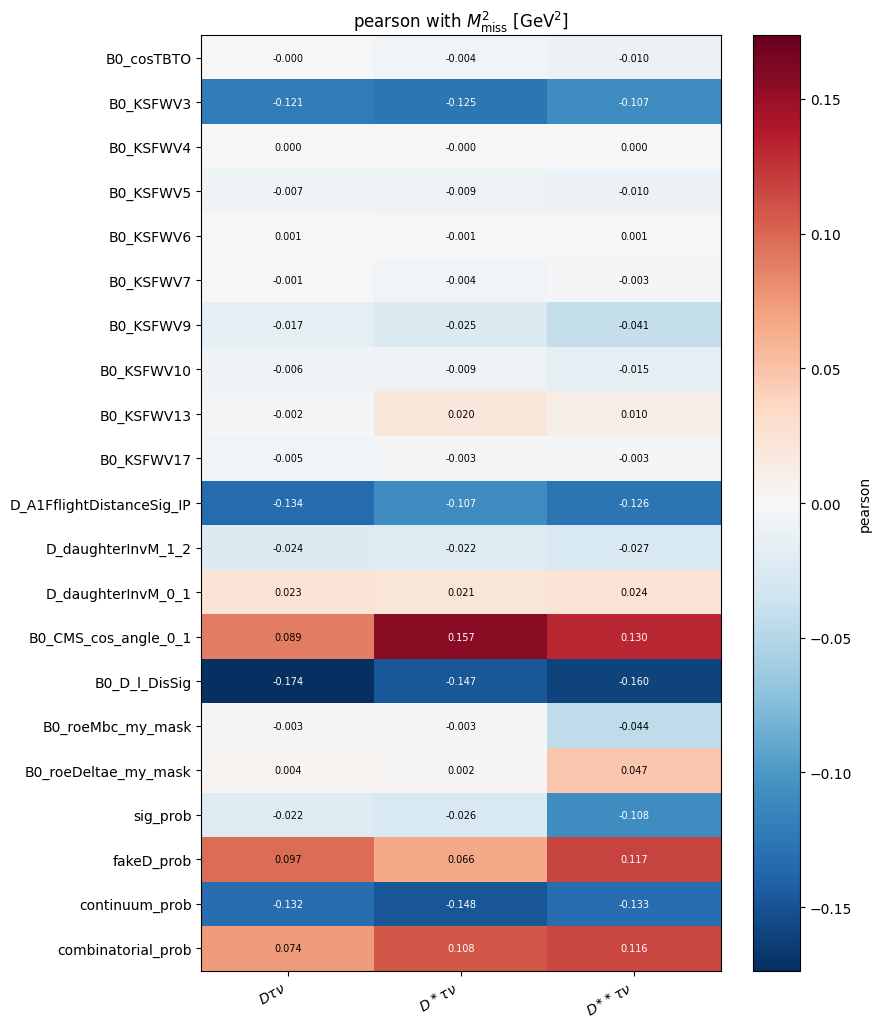

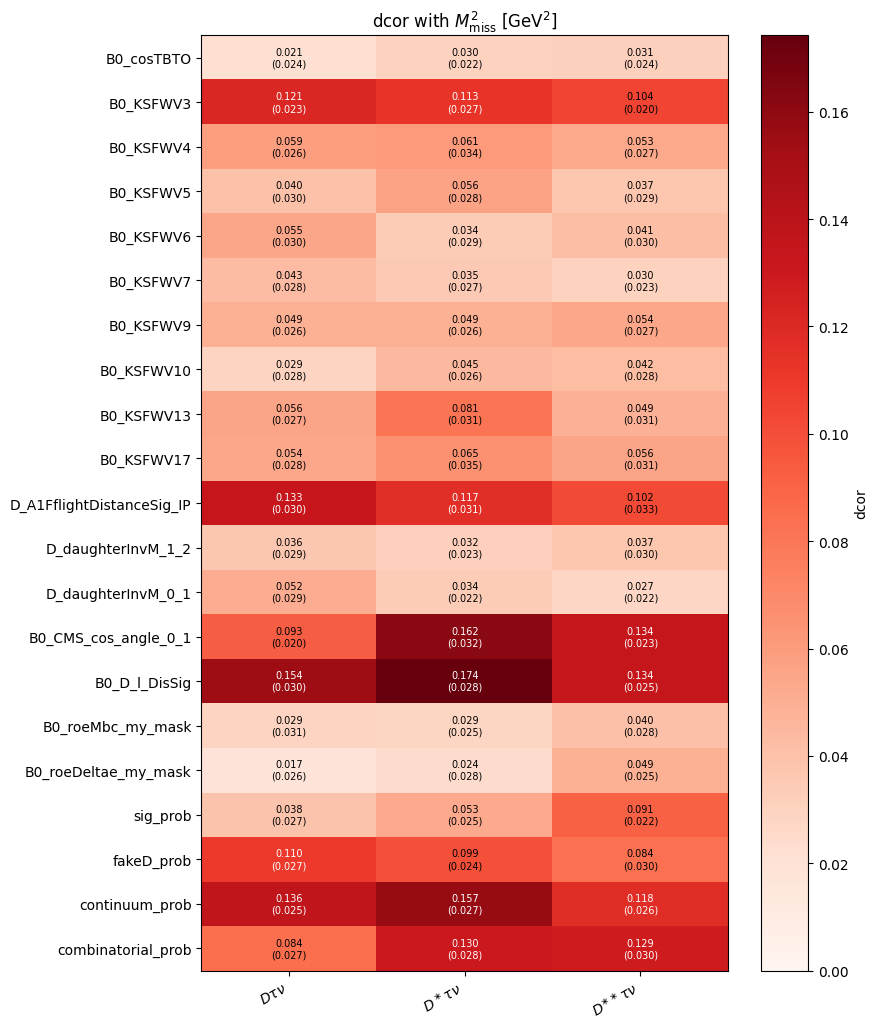

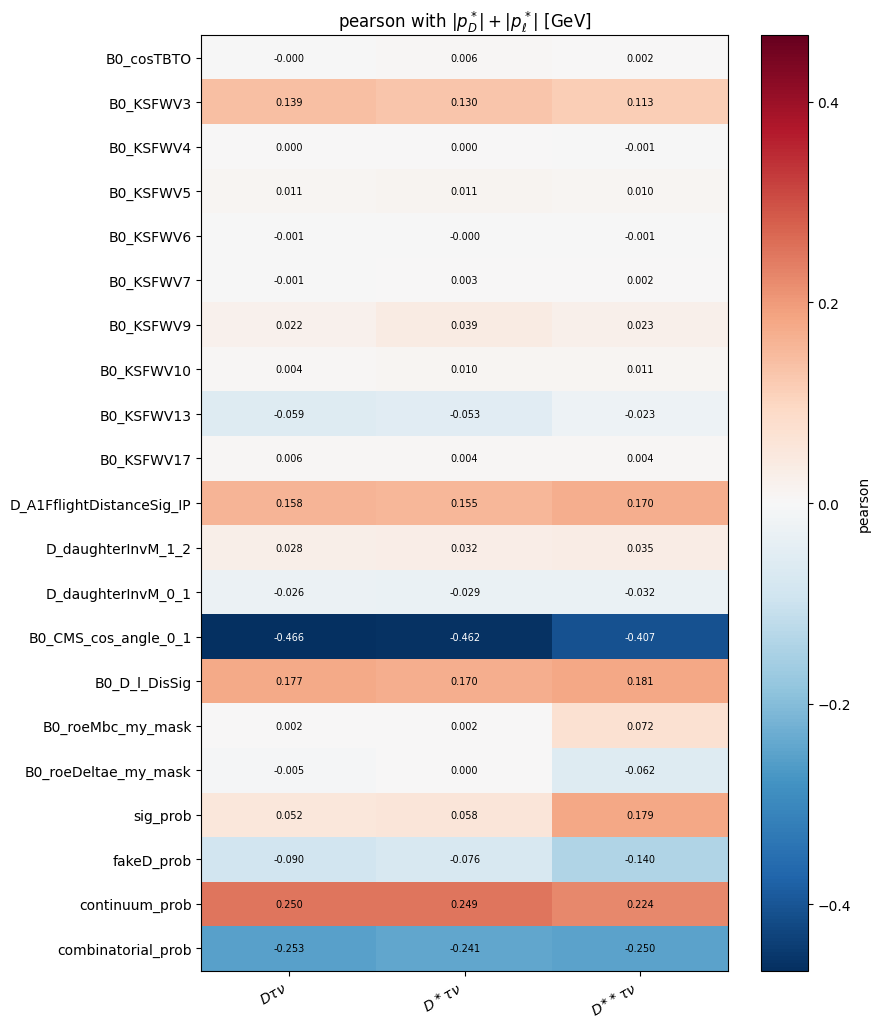

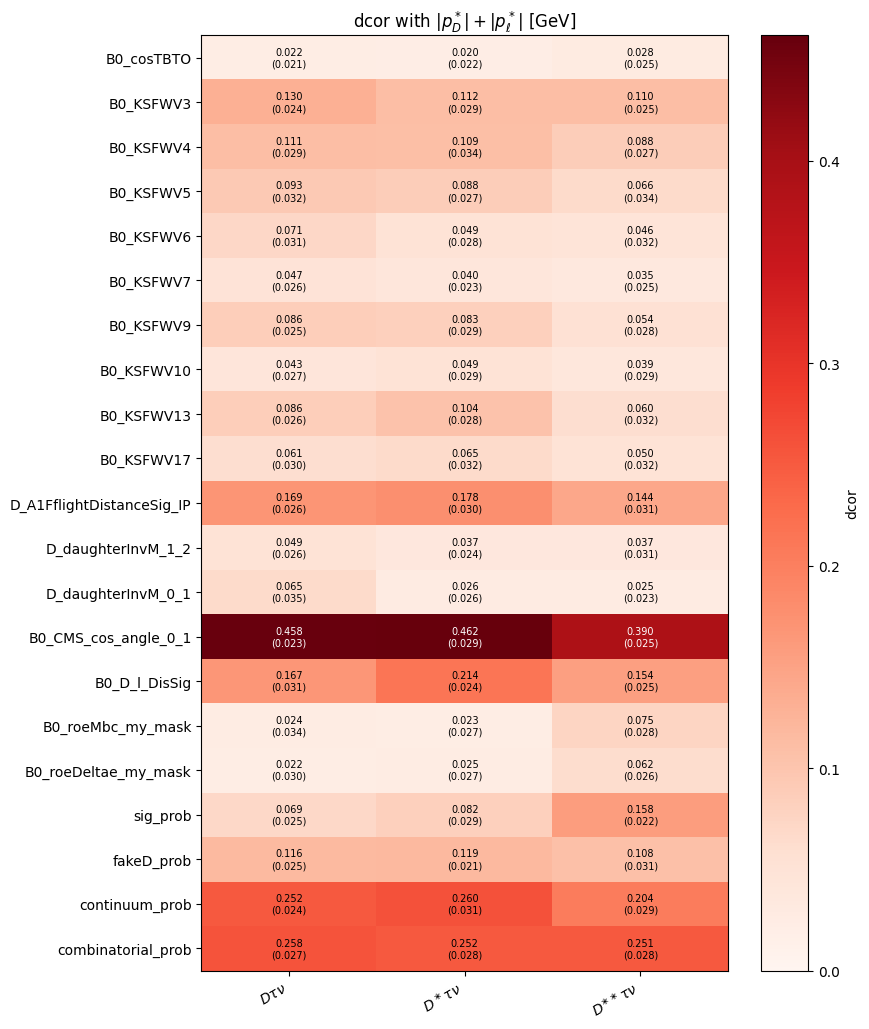

In [9]:
# %% [3] STEP 1: correlation table (training variables + outputs vs. fit variables)
variables = training_variables + util.MVA_OUTPUTS
corr = util.correlation_table(S_all, variables)
for fv in util.FIT_VARIABLES:
    util.plot_correlation_heatmap(corr, fv, metric='pearson', variables=variables)
    util.plot_correlation_heatmap(corr, fv, metric='dcor', variables=variables)
corr.to_csv(f'corr_table_sigMC_{mode}.csv', index=False)

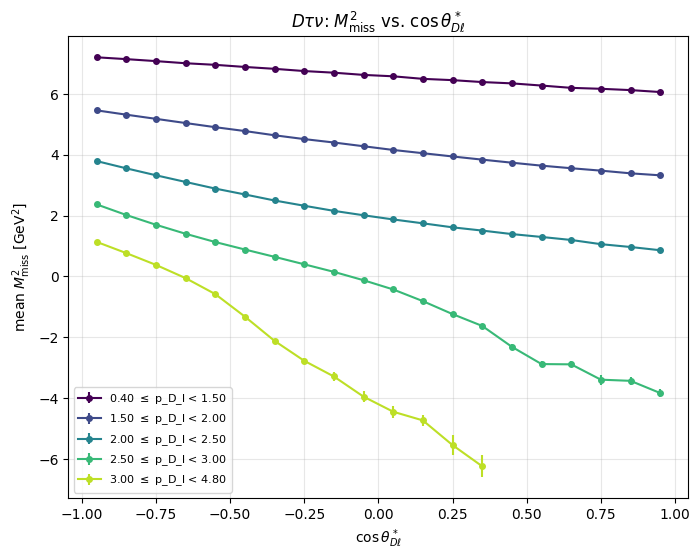

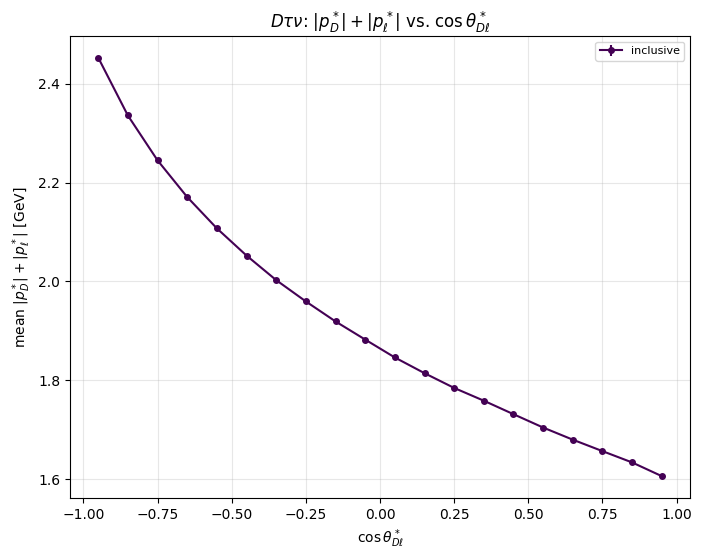

In [11]:
# %% [4] STEP 1b: case study of the D-l opening angle
# MM2 vs cos(theta): sliced in p_D_l to expose the algebraic dependence
fig_mm2 = util.plot_profile_in_slices(S_all[r'$D\tau\nu$'], x='B0_CMS_cos_angle_0_1', y='B0_recMissM2',
                                      bins_x=np.linspace(-1, 1, 21), cond_var='p_D_l',
                                      cond_edges=[0.4, 1.5, 2.0, 2.5, 3.0, 4.8],
                                      xlabel=r'$\cos\theta^*_{D\ell}$',
                                      title=r'$D\tau\nu$: $M_{\mathrm{miss}}^2$ vs. $\cos\theta^*_{D\ell}$')

# p_D_l vs cos(theta): inclusive, since slicing in p_D_l itself would be trivially flat
fig_pdl = util.plot_profile_in_slices(S_all[r'$D\tau\nu$'], x='B0_CMS_cos_angle_0_1', y='p_D_l',
                                      bins_x=np.linspace(-1, 1, 21),
                                      xlabel=r'$\cos\theta^*_{D\ell}$',
                                      title=r'$D\tau\nu$: $|p^*_D|+|p^*_\ell|$ vs. $\cos\theta^*_{D\ell}$')

In [8]:
# %% [5] STEP 2a: full-range quantile slicing
# summary table: one row per (component, slice_var, slice, test_on) with chi2, p,
# tvd, tvd_null, max_rel_dev, max_rel_dev_err
q_full = util.run_quantile_study(S_all, slice_vars=util.MVA_OUTPUTS, n_slices=5,
                                 plots=('1d',), save_dir=f'plots/decorr/{mode}/full_range', show=False)

In [9]:
# %% [6] STEP 2b: N-1 quantile slicing around the working point
q_nm1 = util.run_quantile_study(S_all, slice_vars=util.MVA_OUTPUTS, n_slices=5,
                                base_cuts=util.n_minus_1_base_cuts(util.lgb_tight),
                                plots=('1d',), save_dir=f'plots/decorr/{mode}/nminus1', show=False)

In [11]:
# %% [7] STEP 3a: working point on the full candidate-level sample
# lgb_tight implies every lgb_loose condition, so its passing candidates are the
# ones the fit chain keeps before BCS. Pass vs. fail, plus N-1 per condition.
MM2_bins = np.concatenate((np.linspace(-2.5, 2.5, 11), np.linspace(2.8, 10, 31)))
p_D_l_bins = np.concatenate(([0.4, 0.6, 0.8], np.linspace(1, 3, 41),
                             [3.1, 3.2, 3.3, 3.4, 3.6, 3.8, 4, 4.2, 4.4, 4.6, 4.8]))
wp_tables, wp_figs = [], {}
for comp, df in S_all.items():
    t, figs = util.n_minus_1_study(df, util.lgb_tight, fit_bins=[MM2_bins, p_D_l_bins],
                                   map_type='rel', save_dir=f'plots/decorr/{mode}/working_point',
                                   show=False, tag=comp)
    wp_tables.append(t)
    wp_figs[comp] = figs
wp = pd.concat(wp_tables, ignore_index=True)
wp[['sample', 'test', 'status', 'test_on', 'f_pass', 'n_a', 'n_b', 'tvd', 'tvd_null', 'tvd_vs_input',
    'max_rel_dev', 'max_rel_dev_err']]

$D\tau\nu$ N-1: combinatorial_prob<0.6: skipped: no candidate fails it (redundant given the base cut) (pass=616192, fail=0)
$D^\ast\tau\nu$ N-1: combinatorial_prob<0.6: skipped: no candidate fails it (redundant given the base cut) (pass=271951, fail=0)
$D^{\ast\ast}\tau\nu$ N-1: combinatorial_prob<0.6: skipped: no candidate fails it (redundant given the base cut) (pass=224468, fail=0)


,sample,test,status,test_on,f_pass,n_a,n_b,tvd,tvd_null,tvd_vs_input,max_rel_dev,max_rel_dev_err
0,$D\tau\nu$,full cut,ok,B0_recMissM2,0.250414,616192,1844502,0.079249,0.002450,0.059398,-0.492439,0.008100
1,$D\tau\nu$,full cut,ok,p_D_l,0.250414,616192,1844502,0.094727,0.002096,0.071006,-0.536763,0.005537
2,$D\tau\nu$,full cut,ok,2d,0.250414,616192,1844502,0.102794,0.004873,0.077046,0.514757,0.029587
3,$D\tau\nu$,full cut,ok,2d_fit_binning,0.250414,616192,1844502,0.108095,0.012909,0.081019,0.367862,0.025331
4,$D\tau\nu$,N-1: sig_prob>0.5,ok,B0_recMissM2,0.897052,616192,70716,0.019308,0.006460,0.001986,0.089871,0.019244
5,$D\tau\nu$,N-1: sig_prob>0.5,ok,p_D_l,0.897052,616192,70716,0.104047,0.005493,0.010711,0.488023,0.024148
6,$D\tau\nu$,N-1: sig_prob>0.5,ok,2d,0.897052,616192,70716,0.224776,0.012661,0.023119,-0.398018,0.010574
7,$D\tau\nu$,N-1: sig_prob>0.5,ok,2d_fit_binning,0.897052,616192,70716,0.240908,0.033315,0.024778,NaN,NaN
8,$D\tau\nu$,N-1: fakeD_prob<0.06,ok,B0_recMissM2,0.428512,616192,821789,0.095850,0.002791,0.054778,-0.526451,0.008134
9,$D\tau\nu$,N-1: fakeD_prob<0.06,ok,p_D_l,0.428512,616192,821789,0.095564,0.002380,0.054614,-0.539950,0.005934


In [ ]:
# %% [8] STEP 3b: BCS effect (BCS on ALL post-loose candidates, then classify)
# cand = sig_all.query(util.lgb_loose).reset_index(drop=True)
# cand = util.add_bcs_flag(cand)
# S_bcs = util.prepare_decorrelation_samples(cand, mode, components=[r'$D\tau\nu$'])
# for comp, df in S_bcs.items():
#     util.compare_fit_variable_shapes(df[df.bcs_selected], df[~df.bcs_selected],
#                                      labels=('BCS selected', 'BCS rejected'),
#                                      title=f'{comp}: BCS selected vs. rejected (after lgb_loose)')

In [ ]:
# %% [9] STEP 3c: transfer checks (generic MC, once available)
# gen_loose / gen_comb: post-BCS trees MC_{mode}_loose and MC_{mode}_comb, reset_index(drop=True)
# combinatorial: tight region vs. lgb_comb control region (disjoint: sig_prob>0.5 & comb>0.5 impossible)
# A = util.prepare_decorrelation_samples(gen_loose.query(util.lgb_tight), mode, components=['bkg_combinatorial'])
# B = util.prepare_decorrelation_samples(gen_comb, mode, components=['bkg_combinatorial'])
# util.compare_fit_variable_shapes(A['bkg_combinatorial'], B['bkg_combinatorial'],
#                                  labels=('tight region', 'comb region'))
# fakeD: D_M signal window vs. sidebands, both after lgb_tight
# A = util.prepare_decorrelation_samples(gen_loose.query(util.lgb_tight), mode,
#                                        d_mass_cut=util.D_MASS_SR, components=['bkg_fakeD'])
# B = util.prepare_decorrelation_samples(gen_loose.query(util.lgb_tight), mode,
#                                        d_mass_cut=util.D_MASS_SB, components=['bkg_fakeD'])
# util.compare_fit_variable_shapes(A['bkg_fakeD'], B['bkg_fakeD'], labels=('D_M SR', 'D_M SB'))